In [ ]:
# =========================================
# CLUSTER ANALYSIS USING K-MEANS
# ON SAMPLE DATASET (IRIS DATASET)
# =========================================

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [ ]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)


In [ ]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
# -----------------------------------------
# Step 1: Load Sample Dataset (Iris)
# -----------------------------------------
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

df = pd. DataFrame(X,columns=feature_names)
print(pd.DataFrame(df))

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [ ]:
# ------------------------------------------
# Step 2: Standardize the Data
# ------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

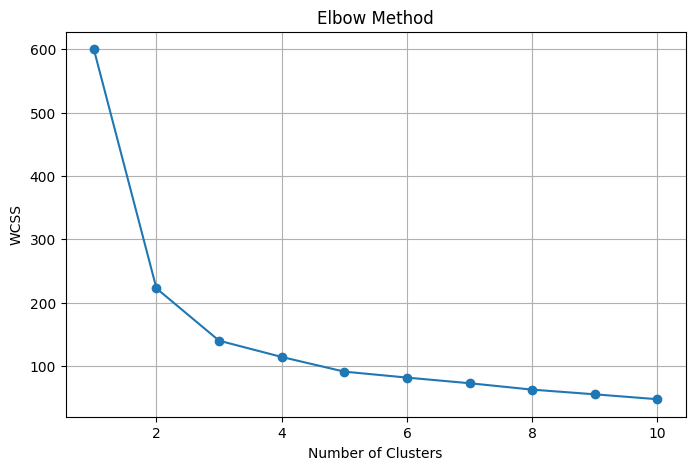

In [ ]:
# --------------------------------------
# Step 3: Elbow Method
# --------------------------------------
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
  kmeans.fit(X_scaled) # Fixed: lowercase 's'
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show() # Fixed: plt instead of plot




In [ ]:
# ------------------------------------------
# Step 4: Apply K-Means (K=3 for Iris)
# ------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = clusters

In [ ]:
# ------------------------------------------
# Step 5: Silhouette Score
# ------------------------------------------
score = silhouette_score(X_scaled, clusters)
print("\nSilhouette Score:", score)


Silhouette Score: 0.45994823920518635


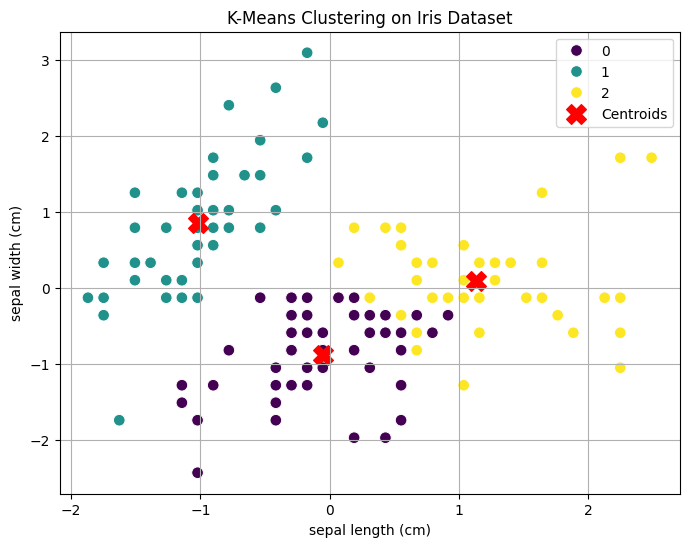


Cluster Centers (Scaled Data):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [ ]:
# ------------------------------------------
# Step 6: Cluster Visualization (2 Features)
# ------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1],
                hue=clusters, palette='viridis', s=70)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, c='red', marker='X', label='Centroids')

plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------
# Step 7: Print Cluster Centers
# ------------------------------------------
print("\nCluster Centers (Scaled Data):")
print(centroids)